In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

In [2]:
# Set a professional visualization theme
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [3]:
# 1. Load the dataset (Make sure the Kaggle CSV file is in your folder)
df = pd.read_csv('../dataset/Telco-Customer-Churn.csv')

In [4]:
# 2. Data Cleaning: 'TotalCharges' sometimes has blank spaces instead of NaNs, converting it to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Drop 'customerID' as it has no predictive power
df.drop('customerID', axis=1, inplace=True)

In [5]:
# 3. Target Variable Setup: Map 'Churn' to 1 (Yes) and 0 (No)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

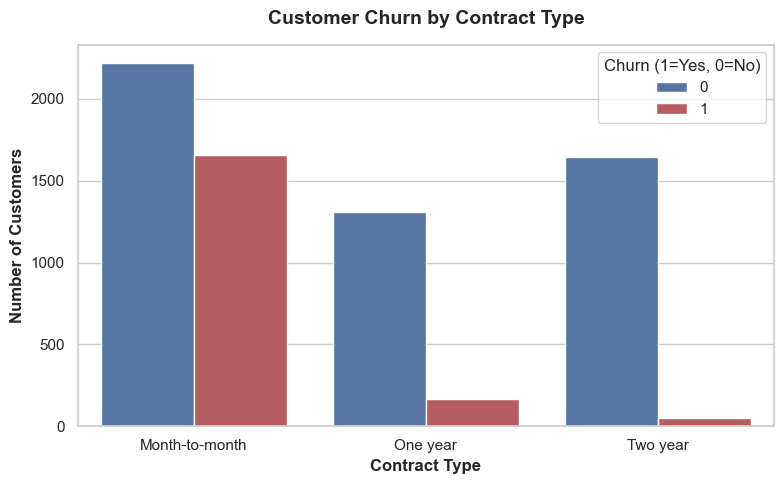

In [6]:
# EDA: Visualizing the relationship between Contract type and Churn
plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', hue='Churn', data=df, palette=['#4c72b0', '#c44e52'])
plt.title('Customer Churn by Contract Type', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Contract Type', fontsize=12, fontweight='semibold')
plt.ylabel('Number of Customers', fontsize=12, fontweight='semibold')
plt.legend(title='Churn (1=Yes, 0=No)')
plt.tight_layout()
plt.show()

# Insight: Month-to-month contracts have a significantly higher churn rate.

In [7]:
# 4. Handle Categorical Variables using One-Hot Encoding (get_dummies)
# drop_first=True prevents the dummy variable trap
X = pd.get_dummies(df.drop('Churn', axis=1), drop_first=True)
y = df['Churn']

# Task Note regarding Class Imbalance:
# The Telco dataset is imbalanced (~73% No Churn, ~27% Churn).
# We will handle this by using `class_weight='balanced'` in our models, 
# and by using 'stratify=y' in our train-test split.

# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
# 1. Train Logistic Regression Model
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# 2. Train Decision Tree Classifier
# Using max_depth to avoid overfitting the tree
dt_model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

# Compare Performance
print("--- Logistic Regression Performance ---")
print(classification_report(y_test, lr_preds))

print("\n--- Decision Tree Classifier Performance ---")
print(classification_report(y_test, dt_preds))

--- Logistic Regression Performance ---
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


--- Decision Tree Classifier Performance ---
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.81      0.62       374

    accuracy                           0.73      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.73      0.75      1409



Top 3 Features Driving Churn:
Contract_Two year              0.405269
Contract_One year              0.253452
InternetService_Fiber optic    0.111558
dtype: float64


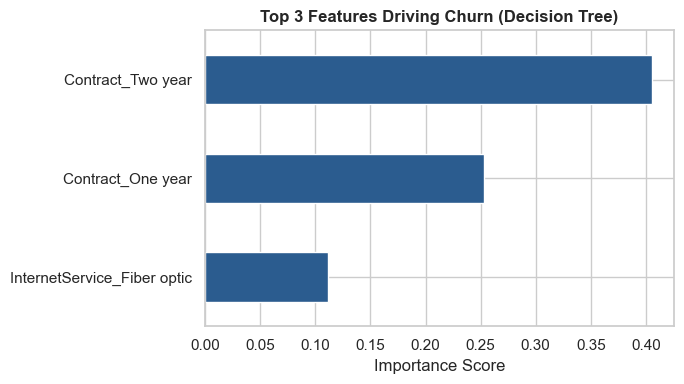

In [9]:
# Identify the top 3 features using the Decision Tree's feature_importances_
feature_importances = pd.Series(dt_model.feature_importances_, index=X.columns)
top_3_features = feature_importances.nlargest(3)

print("Top 3 Features Driving Churn:")
print(top_3_features)

# Visualize the top 3 features
plt.figure(figsize=(7, 4))
top_3_features.plot(kind='barh', color='#2b5c8f')
plt.title('Top 3 Features Driving Churn (Decision Tree)', fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis() # Highest importance at the top
plt.tight_layout()
plt.show()

#### Business Summary:

Based on our predictive modeling, we have successfully identified the key drivers behind why customers leave our service. The most critical factor is the Contract Type; customers on flexible, month-to-month contracts are significantly more likely to churn compared to those on stable one or two-year commitments. Additionally, Tenure (how long a customer has been with us) and Monthly Charges play major roles, indicating that newer customers facing higher bills are at the greatest risk of leaving. To reduce this churn, the business should focus its retention strategies on incentivizing month-to-month customers to switch to long-term contracts by offering targeted discounts or loyalty perks early in their lifecycle. Our machine learning models are now capable of flagging these at-risk customers proactively, allowing the retention team to intervene before the customer decides to cancel.